In [47]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

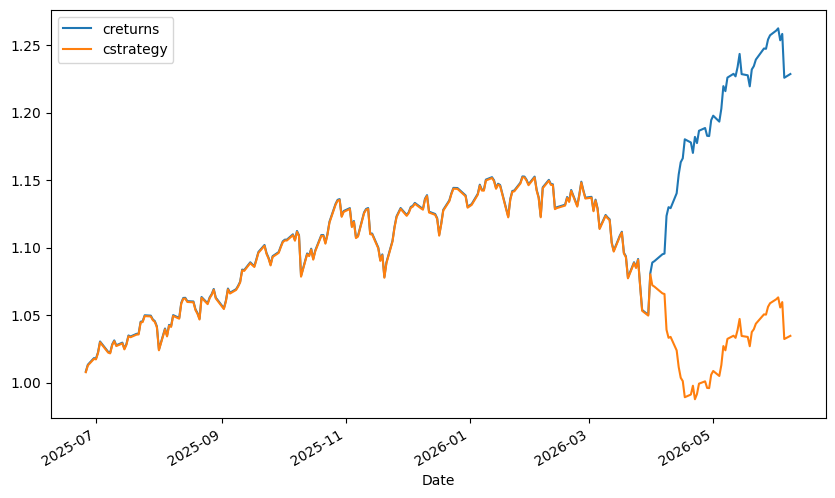

In [48]:
data=yf.Ticker('SPY')
df=data.history(period='5y')
train=df.iloc[:-242]
test=df.iloc[-242:]
train=train[["Close"]]
train["Shifted Close"]=train["Close"].shift(1)
train["returns"]=np.log(train["Close"]/train["Shifted Close"])
train.dropna(inplace=True)
train["creturns"]=np.exp(train["returns"].cumsum())
train_copy=train.copy()
best_fit=[]

for i in range(10,60,5):
    for j in range(100,200,10):
        train_copy[f"{i}d"]=train_copy["Close"].rolling(i).mean()
        train_copy[f"{j}d"]=train_copy["Close"].rolling(j).mean()
        train_copy.dropna(inplace=True)
        train_copy["position"]=np.where(train_copy[f"{i}d"]>train_copy[f"{j}d"],1,-1)
        train_copy["strategy"]=train_copy["returns"]*train_copy["position"].shift(1)
        train_copy.dropna(inplace=True)
        train_copy["cstrategy"]=np.exp(train_copy["strategy"].cumsum())
        best_fit.append((i,j,train_copy["cstrategy"].iloc[-1]))
        train_copy = train.copy()
    
best_value=best_fit[0][2]
best_i=best_fit[0][0]
best_j=best_fit[0][1]
for i,j,value in best_fit:
    if value>best_value:
        best_value=value
        best_i=i
        best_j=j


df=df[["Close"]]
df[f"{best_i}d"]=df["Close"].rolling(best_i).mean()
df[f"{best_j}d"]=df["Close"].rolling(best_j).mean()

       

test=test[["Close"]]
test["Shifted Close"]=test["Close"].shift(1)
test["returns"]=np.log(test["Close"]/test["Shifted Close"])
test.dropna(inplace=True)
test["creturns"]=np.exp(test["returns"].cumsum())
test[f"{best_i}d"] = df.loc[test.index, f"{best_i}d"]
test[f"{best_j}d"] = df.loc[test.index, f"{best_j}d"]
test.dropna(inplace=True)
test["position"]=np.where(test[f"{best_i}d"]>test[f"{best_j}d"],1,-1)
test["strategy"]=test["returns"]*test["position"].shift(1)
test.dropna(inplace=True)
test["cstrategy"]=np.exp(test["strategy"].cumsum())
test[["creturns","cstrategy"]].plot(figsize=(10,6))
plt.show()









In [49]:

results_df = pd.DataFrame(best_fit, columns=['SMA_Short', 'SMA_Long', 'Final_Return'])
top_10 = results_df.sort_values(by='Final_Return', ascending=False).head(10)

print(top_10)

    SMA_Short  SMA_Long  Final_Return
37         25       170      1.418151
48         30       180      1.412196
49         30       190      1.407223
27         20       170      1.388379
18         15       180      1.381788
99         55       190      1.380731
57         35       170      1.380058
38         25       180      1.374102
36         25       160      1.370866
65         40       150      1.362739


Mentioned above are the pairs of best parameters we found using the data of first four years and then to test it we chose the best performing(25,170) and tested it on the last years data